In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
def histogram_features(image):
    if len(image.shape) == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        image_gray = image
    
    hist = cv2.calcHist([image_gray], [0], None, [256], [0, 256])
    hist = hist.flatten()
    hist = hist / hist.sum()  
    
    values = np.arange(256)
    features = {}
    
    mean_val = np.sum(hist * values)
    features['mean'] = mean_val
    
    variance = np.sum(hist * (values - mean_val) ** 2)
    std_val = np.sqrt(variance)
    features['std'] = std_val
    
    if std_val > 0:
        standardized = (values - mean_val) / std_val
        features['skewness'] = np.sum(hist * standardized ** 3)
    else:
        features['skewness'] = 0.0
    
    if std_val > 0:
        standardized = (values - mean_val) / std_val
        features['kurtosis'] = np.sum(hist * standardized ** 4) - 3.0
    else:
        features['kurtosis'] = -3.0
    
    non_zero_mask = hist > 0
    if np.any(non_zero_mask):
        non_zero_probs = hist[non_zero_mask]
        features['entropy'] = -np.sum(non_zero_probs * np.log2(non_zero_probs))
    else:
        features['entropy'] = 0.0
    
    cumulative_hist = np.cumsum(hist)
    
    q1_index = np.where(cumulative_hist >= 0.25)[0]
    features['q1'] = q1_index[0] if len(q1_index) > 0 else 0
    
    q2_index = np.where(cumulative_hist >= 0.5)[0]
    features['q2'] = q2_index[0] if len(q2_index) > 0 else 0
    
    q3_index = np.where(cumulative_hist >= 0.75)[0]
    features['q3'] = q3_index[0] if len(q3_index) > 0 else 0
    
    non_zero_bins = np.where(hist > 0)[0]
    if len(non_zero_bins) > 0:
        features['min'] = non_zero_bins[0]
        features['max'] = non_zero_bins[-1]
    else:
        features['min'] = 0
        features['max'] = 255
    
    return features, hist, image_gray

In [3]:
def analyze_histogram_categories(image_folder, num_examples=2):
    if not os.path.exists(image_folder):
        print(f"Ошибка: Папка '{image_folder}' не существует")
        return
    
    texture_categories = [
        category for category in os.listdir(image_folder)
        if os.path.isdir(os.path.join(image_folder, category))
    ]
    
    if not texture_categories:
        print("Ошибка: В указанной папке нет подпапок с категориями")
        return
    
    num_to_show = min(num_examples, len(texture_categories))
    
    fig, axes = plt.subplots(
        num_to_show, 
        3, 
        figsize=(15, 4 * num_to_show),
        squeeze=False 
    )
    
    for i in range(num_to_show):
        category = texture_categories[i]
        category_path = os.path.join(image_folder, category)
        
        valid_extensions = ('.png', '.jpeg')
        image_files = [
            f for f in os.listdir(category_path)
            if f.lower().endswith(valid_extensions)
        ]
    
        
        first_image_file = image_files[0]
        image_path = os.path.join(category_path, first_image_file)
        
        image = cv2.imread(image_path)
        
        features, hist, image_gray = histogram_features(image)
        
        if len(image.shape) == 3:
            display_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            display_image = image_gray
            display_image = cv2.cvtColor(display_image, cv2.COLOR_GRAY2RGB)
        
        axes[i, 0].imshow(display_image)
        axes[i, 0].set_title(f'Категория: {category}', fontsize=14, fontweight='bold')
        axes[i, 0].axis('off')
        
        axes[i, 1].bar(range(256), hist, alpha=0.7, color='blue', width=1.0)
        axes[i, 1].set_title('Гистограмма яркости', fontsize=12, fontweight='bold')
        axes[i, 1].set_xlabel('Значение яркости (0-255)', fontsize=10)
        axes[i, 1].set_ylabel('Вероятность', fontsize=10)
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].set_xlim(0, 255)
        
        axes[i, 1].axvline(x=features['mean'], color='red', linestyle='--', 
                          linewidth=1.5, label=f"Mean: {features['mean']:.1f}")
        axes[i, 1].axvline(x=features['q2'], color='green', linestyle=':', 
                          linewidth=1.5, label=f"Median: {features['q2']}")
        axes[i, 1].legend(fontsize=8)
        
        metrics_text = (
            f"Основные характеристики:\n"
            f"• Средняя яркость: {features['mean']:.2f}\n"
            f"• Контрастность: {features['std']:.2f}\n"
            f"• Асимметрия: {features['skewness']:.2f}\n"
            f"• Эксцесс: {features['kurtosis']:.2f}\n"
            f"• Энтропия: {features['entropy']:.2f}\n"
            f"• Квартили: Q1={features['q1']}, Q2={features['q2']}, Q3={features['q3']}\n"
            f"• Диапазон: [{features['min']}, {features['max']}]"
        )
        
        axes[i, 2].text(0.05, 0.95, metrics_text, transform=axes[i, 2].transAxes,
                       fontsize=10, verticalalignment='top', linespacing=1.4,
                       fontfamily='monospace', bbox=dict(boxstyle="round,pad=0.3",
                       facecolor="aliceblue", alpha=0.8))
        axes[i, 2].set_title('Статистические характеристики', fontsize=12, fontweight='bold')
        axes[i, 2].axis('off')
        
        fig.text(0.5, 0.01, f"Файл: {first_image_file}", 
                ha='center', fontsize=9, style='italic', alpha=0.7)
    
    fig.suptitle('Анализ гистограмм по категориям текстур', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.98])
    plt.show()
    
    return texture_categories[:num_to_show]

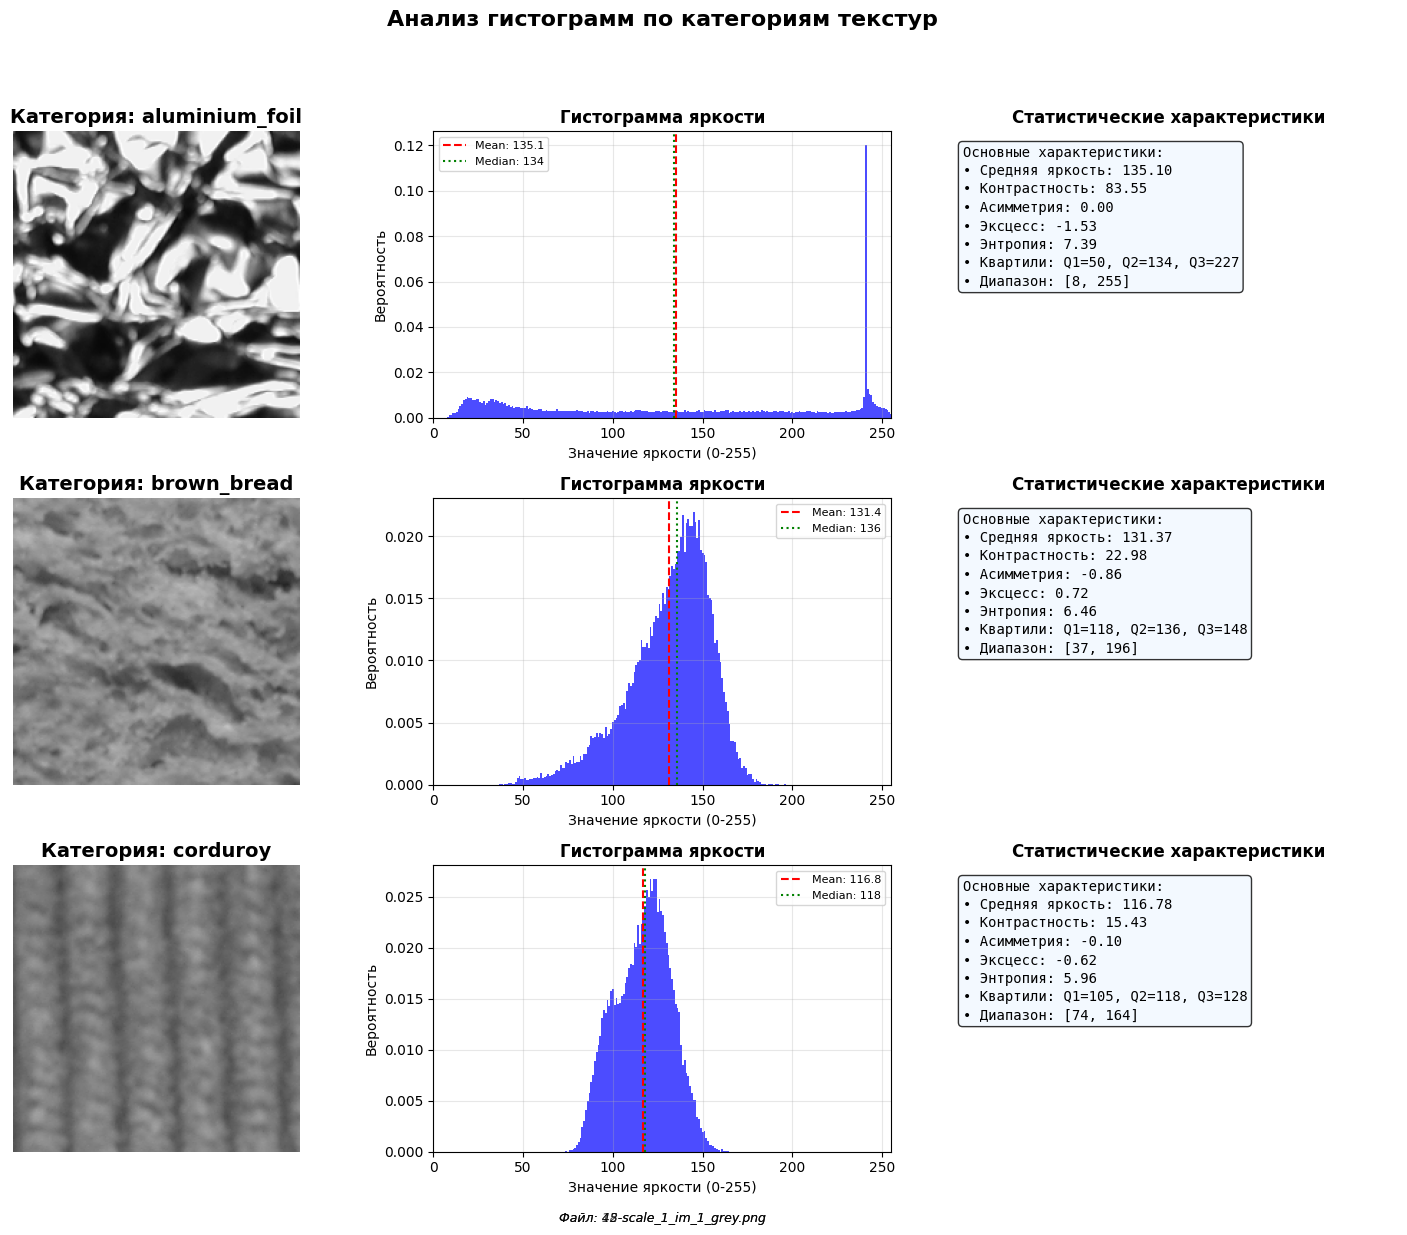

['aluminium_foil', 'brown_bread', 'corduroy']

In [4]:
analyze_histogram_categories("./KTH_TIPS", num_examples=3)

In [5]:
def Laws_features(image):
    L5 = np.array([1, 4, 6, 4, 1], dtype=np.float32)     
    E5 = np.array([-1, -2, 0, 2, 1], dtype=np.float32)   
    S5 = np.array([-1, 0, 2, 0, -1], dtype=np.float32)    
    W5 = np.array([-1, 2, 0, -2, 1], dtype=np.float32)   
    R5 = np.array([1, -4, 6, -4, 1], dtype=np.float32)    
    
    kernels = [L5, E5, S5, W5, R5]
    kernel_names = ['L5', 'E5', 'S5', 'W5', 'R5']
    
    if len(image.shape) == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        image_gray = image
    
    image_gray_float = image_gray.astype(np.float32)
    
    laws_features = {}
    
    num_kernels = len(kernels)
    
    for i in range(num_kernels):
        for j in range(num_kernels):
            kernel_2d = np.outer(kernels[i], kernels[j])
            
 
            filtered_image = cv2.filter2D(
                image_gray_float, 
                cv2.CV_32F,  
                kernel_2d,
                borderType=cv2.BORDER_REFLECT  
            )
          
            energy = np.mean(np.abs(filtered_image))
            
           
            feature_name = f"{kernel_names[i]}{kernel_names[j]}"
            
          
            laws_features[feature_name] = float(energy)
    
    
    all_energies = list(laws_features.values())
    laws_features['mean_energy'] = float(np.mean(all_energies))
    laws_features['std_energy'] = float(np.std(all_energies))
    laws_features['min_energy'] = float(np.min(all_energies))
    laws_features['max_energy'] = float(np.max(all_energies))
    
   
    level_features = [f for f in laws_features.keys() if f.startswith('L5')]
    if level_features:
        level_values = [laws_features[f] for f in level_features]
        laws_features['L5_mean'] = float(np.mean(level_values))
        laws_features['L5_std'] = float(np.std(level_values))
    
    edge_features = [f for f in laws_features.keys() if f.startswith('E5')]
    if edge_features:
        edge_values = [laws_features[f] for f in edge_features]
        laws_features['E5_mean'] = float(np.mean(edge_values))
        laws_features['E5_std'] = float(np.std(edge_values))
    
    spot_features = [f for f in laws_features.keys() if f.startswith('S5')]
    if spot_features:
        spot_values = [laws_features[f] for f in spot_features]
        laws_features['S5_mean'] = float(np.mean(spot_values))
        laws_features['S5_std'] = float(np.std(spot_values))
    
    wave_features = [f for f in laws_features.keys() if f.startswith('W5')]
    if wave_features:
        wave_values = [laws_features[f] for f in wave_features]
        laws_features['W5_mean'] = float(np.mean(wave_values))
        laws_features['W5_std'] = float(np.std(wave_values))
    
    ripple_features = [f for f in laws_features.keys() if f.startswith('R5')]
    if ripple_features:
        ripple_values = [laws_features[f] for f in ripple_features]
        laws_features['R5_mean'] = float(np.mean(ripple_values))
        laws_features['R5_std'] = float(np.std(ripple_values))
    
    return laws_features, image_gray

In [6]:
def analyze_laws_categories(image_folder, num_examples=2):
    if not os.path.exists(image_folder):
        print(f"Ошибка: Папка '{image_folder}' не существует")
        return
    
    texture_categories = [
        f for f in os.listdir(image_folder) 
        if os.path.isdir(os.path.join(image_folder, f))
    ]
    
    if not texture_categories:
        print("Ошибка: В указанной папке нет подпапок с категориями")
        return
    
    num_categories_to_show = min(num_examples, len(texture_categories))
    
    fig, axes = plt.subplots(
        num_categories_to_show, 
        2, 
        figsize=(14, 4 * num_categories_to_show),
        squeeze=False  
    )
    
    for i in range(num_categories_to_show):
        category = texture_categories[i]
        category_path = os.path.join(image_folder, category)
        
        valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
        image_files = [
            f for f in os.listdir(category_path)
            if f.lower().endswith(valid_extensions)
        ]
        
        if not image_files:
            print(f"Предупреждение: В категории '{category}' нет изображений")
            axes[i, 0].clear()
            axes[i, 0].text(0.5, 0.5, "Нет изображений", 
                           ha='center', va='center', fontsize=12)
            axes[i, 0].axis('off')
            
            axes[i, 1].clear()
            axes[i, 1].text(0.5, 0.5, "Нет данных", 
                           ha='center', va='center', fontsize=12)
            axes[i, 1].axis('off')
            continue
        
        first_image_file = image_files[0]
        first_image_path = os.path.join(category_path, first_image_file)
        
        image = cv2.imread(first_image_path)
        if image is None:
            print(f"Ошибка: Не удалось загрузить изображение '{first_image_path}'")
            axes[i, 0].clear()
            axes[i, 0].text(0.5, 0.5, "Ошибка загрузки", 
                           ha='center', va='center', fontsize=12, color='red')
            axes[i, 0].axis('off')
            
            axes[i, 1].clear()
            axes[i, 1].text(0.5, 0.5, "Нет данных", 
                           ha='center', va='center', fontsize=12, color='red')
            axes[i, 1].axis('off')
            continue
        
        laws_features, img_gray = Laws_features(image)
        
        if len(image.shape) == 3:
            display_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            display_image = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
        
        axes[i, 0].imshow(display_image)
        axes[i, 0].set_title(f'Категория: {category}', fontsize=14, fontweight='bold')
        axes[i, 0].set_xlabel(f"Файл: {first_image_file}", fontsize=9, style='italic')
        axes[i, 0].axis('off')
        
        base_laws_features = {
            k: v for k, v in laws_features.items() 
            if len(k) == 4  
        }
        
        sorted_laws = sorted(
            base_laws_features.items(), 
            key=lambda x: x[1], 
            reverse=True
        )[:9]
        
        laws_text = "Топ 9 Laws признаков:\n\n"
        
        max_value = max(v for _, v in sorted_laws) if sorted_laws else 1
        
        for name, value in sorted_laws:
            normalized_value = value / max_value
            
            if normalized_value > 0.8:
                color_tag = "[HIGH]"
            elif normalized_value > 0.5:
                color_tag = "[MIDDLE]"  
            elif normalized_value > 0.2:
                color_tag = "[LOW]" 
            else:
                color_tag = "[VERY LOW]"  
            
            laws_text += f"{color_tag} {name}: {value:.4f}\n"
        
        if 'mean_energy' in laws_features:
            laws_text += f"\nОбщая статистика:\n"
            laws_text += f"• Средняя энергия: {laws_features['mean_energy']:.4f}\n"
            laws_text += f"• Стандартное отклонение: {laws_features['std_energy']:.4f}\n"
            laws_text += f"• Диапазон: [{laws_features['min_energy']:.4f}, "
            laws_text += f"{laws_features['max_energy']:.4f}]"
        
        axes[i, 1].text(0.05, 0.95, laws_text, transform=axes[i, 1].transAxes, 
                       fontsize=10, verticalalignment='top', linespacing=1.4,
                       fontfamily='monospace', 
                       bbox=dict(boxstyle="round,pad=0.4", 
                                 facecolor="aliceblue", 
                                 alpha=0.8,
                                 edgecolor='navy'))
        
        axes[i, 1].set_title('Текстурные признаки Laws', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
    
    
    fig.suptitle('Анализ текстурных признаков Laws по категориям', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.98])
    plt.show()
    
    return texture_categories[:num_categories_to_show]

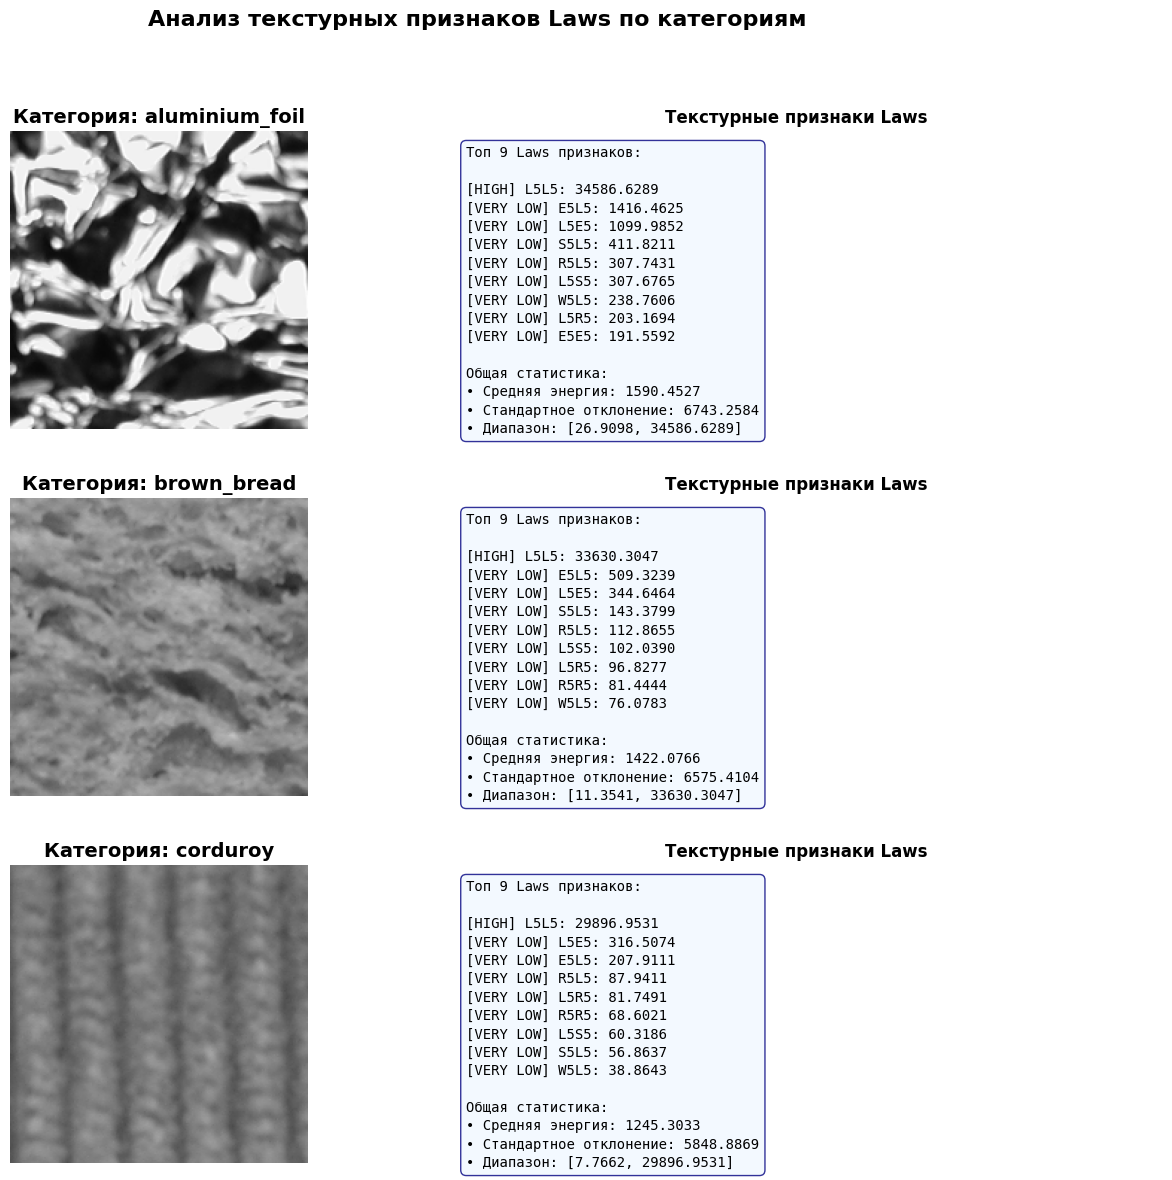

['aluminium_foil', 'brown_bread', 'corduroy']

In [7]:
analyze_laws_categories("./KTH_TIPS", num_examples=3)

In [8]:
def GLCM_features(image):
    
    if len(image.shape) == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        image_gray = image
    
    img_quantized = (image_gray / 32).astype(np.uint8)
    
    distances = [1, 2] 
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    levels = 8  
    
    glcm_matrix = graycomatrix(
        img_quantized,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,    
        normed=True        
    )
    
    properties = [
        'contrast',     
        'dissimilarity',
        'homogeneity',   
        'energy',       
        'correlation'   
    ]
    
    glcm_features = {}
    
    for prop in properties:
        prop_values = graycoprops(glcm_matrix, prop)
        
        for dist_idx, distance in enumerate(distances):
            for angle_idx, angle in enumerate(angles):
                angle_deg = int(angle * 180 / np.pi)
                
                feature_name = f"{prop}_d{distance}_a{angle_deg}"
                
                glcm_features[feature_name] = float(prop_values[dist_idx, angle_idx])
    
    for prop in properties:
        prop_features = [v for k, v in glcm_features.items() if k.startswith(prop)]
        if prop_features:
            glcm_features[f"{prop}_mean"] = float(np.mean(prop_features))
            glcm_features[f"{prop}_std"] = float(np.std(prop_features))
            glcm_features[f"{prop}_min"] = float(np.min(prop_features))
            glcm_features[f"{prop}_max"] = float(np.max(prop_features))
    
    for distance in distances:
        dist_features = [v for k, v in glcm_features.items() if f"_d{distance}_" in k]
        if dist_features:
            glcm_features[f"dist_{distance}_mean"] = float(np.mean(dist_features))
            glcm_features[f"dist_{distance}_std"] = float(np.std(dist_features))
    
    for angle_deg in [0, 45, 90, 135]:
        angle_features = [v for k, v in glcm_features.items() if f"_a{angle_deg}" in k]
        if angle_features:
            glcm_features[f"angle_{angle_deg}_mean"] = float(np.mean(angle_features))
            glcm_features[f"angle_{angle_deg}_std"] = float(np.std(angle_features))
    
    all_glcm_values = list(glcm_features.values())
    glcm_features['glcm_overall_mean'] = float(np.mean(all_glcm_values))
    glcm_features['glcm_overall_std'] = float(np.std(all_glcm_values))
    glcm_features['glcm_overall_range'] = float(np.max(all_glcm_values) - np.min(all_glcm_values))
    
    for dist_idx, distance in enumerate(distances):
        for angle_idx, angle_deg in enumerate([0, 45, 90, 135]):
            pair_features = []
            for prop in properties:
                feature_name = f"{prop}_d{distance}_a{angle_deg}"
                if feature_name in glcm_features:
                    pair_features.append(glcm_features[feature_name])
            
            if pair_features:
                pair_name = f"pair_d{distance}_a{angle_deg}"
                glcm_features[f"{pair_name}_mean"] = float(np.mean(pair_features))
    
    return glcm_features, image_gray

In [9]:
def analyze_glcm_categories(image_folder, num_examples=2):
    if not os.path.exists(image_folder):
        print(f"Ошибка: Папка '{image_folder}' не существует")
        return
    
    texture_categories = [
        f for f in os.listdir(image_folder) 
        if os.path.isdir(os.path.join(image_folder, f))
    ]
    
    if not texture_categories:
        print("Ошибка: В указанной папке нет подпапок с категориями")
        return
    
    num_categories_to_show = min(num_examples, len(texture_categories))
    
    fig, axes = plt.subplots(
        num_categories_to_show, 
        2, 
        figsize=(16, 6 * num_categories_to_show),
        squeeze=False  
    )
    
    def get_best_value(features_dict, feature_type):
        if not features_dict:
            return 0.0
        
        if feature_type in ['contrast', 'dissimilarity']:
            return np.min(list(features_dict.values()))
        else:
            return np.max(list(features_dict.values()))
    
    for i in range(num_categories_to_show):
        category = texture_categories[i]
        category_path = os.path.join(image_folder, category)
        
        valid_extensions = ('.png', '.jpeg')
        image_files = [
            f for f in os.listdir(category_path)
            if f.lower().endswith(valid_extensions)
        ]
        
        first_image_file = image_files[0]
        first_image_path = os.path.join(category_path, first_image_file)
        
        image = cv2.imread(first_image_path)
        if image is None:
            print(f"Ошибка: Не удалось загрузить изображение '{first_image_path}'")
            axes[i, 0].clear()
            axes[i, 0].text(0.5, 0.5, "Ошибка загрузки", 
                           ha='center', va='center', fontsize=12, color='red')
            axes[i, 0].axis('off')
            
            axes[i, 1].clear()
            axes[i, 1].text(0.5, 0.5, "Нет данных", 
                           ha='center', va='center', fontsize=12, color='red')
            axes[i, 1].axis('off')
            continue

        glcm_features, img_gray = GLCM_features(image)

        if len(image.shape) == 3:
            display_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            display_image = img_gray
            display_image = cv2.cvtColor(display_image, cv2.COLOR_GRAY2RGB)
        
        axes[i, 0].imshow(display_image)
        axes[i, 0].set_title(f'Категория: {category}', fontsize=14, fontweight='bold')
        axes[i, 0].set_xlabel(f"Файл: {first_image_file}", fontsize=9, style='italic')
        axes[i, 0].axis('off')
        
        main_features = {k: v for k, v in glcm_features.items() 
                        if any(prop in k for prop in ['contrast', 'dissimilarity', 
                                                     'homogeneity', 'energy', 'correlation']) 
                        and '_mean' not in k and '_std' not in k 
                        and '_min' not in k and '_max' not in k}
        
        contrast_features = {k: v for k, v in main_features.items() if 'contrast' in k}
        dissimilarity_features = {k: v for k, v in main_features.items() if 'dissimilarity' in k}
        homogeneity_features = {k: v for k, v in main_features.items() if 'homogeneity' in k}
        energy_features = {k: v for k, v in main_features.items() if 'energy' in k}
        correlation_features = {k: v for k, v in main_features.items() if 'correlation' in k}
        
        glcm_text = "GLCM Текстурные характеристики:\n\n"
        
        best_contrast = get_best_value(contrast_features, 'contrast')
        contrast_mean = glcm_features.get('contrast_mean', 0)
        contrast_std = glcm_features.get('contrast_std', 0)
        glcm_text += f"Контрастность:\n"
        glcm_text += f"Лучшее значение: {best_contrast:.4f}\n"
        glcm_text += f"Среднее: {contrast_mean:.4f} (±{contrast_std:.4f})\n"
        glcm_text += f"Диапазон: {glcm_features.get('contrast_min', 0):.4f}-"
        glcm_text += f"{glcm_features.get('contrast_max', 0):.4f}\n\n"
        
        best_homogeneity = get_best_value(homogeneity_features, 'homogeneity')
        homogeneity_mean = glcm_features.get('homogeneity_mean', 0)
        homogeneity_std = glcm_features.get('homogeneity_std', 0)
        glcm_text += f"Однородность:\n"
        glcm_text += f"Лучшее значение: {best_homogeneity:.4f}\n"
        glcm_text += f"Среднее: {homogeneity_mean:.4f} (±{homogeneity_std:.4f})\n"
        glcm_text += f"Диапазон: {glcm_features.get('homogeneity_min', 0):.4f}-"
        glcm_text += f"{glcm_features.get('homogeneity_max', 0):.4f}\n\n"
        
        best_energy = get_best_value(energy_features, 'energy')
        energy_mean = glcm_features.get('energy_mean', 0)
        energy_std = glcm_features.get('energy_std', 0)
        glcm_text += f"Энергия:\n"
        glcm_text += f"Лучшее значение: {best_energy:.4f}\n"
        glcm_text += f"Среднее: {energy_mean:.4f} (±{energy_std:.4f})\n"
        glcm_text += f"Диапазон: {glcm_features.get('energy_min', 0):.4f}-"
        glcm_text += f"{glcm_features.get('energy_max', 0):.4f}\n\n"
        
        best_correlation = get_best_value(correlation_features, 'correlation')
        correlation_mean = glcm_features.get('correlation_mean', 0)
        correlation_std = glcm_features.get('correlation_std', 0)
        glcm_text += f"Корреляция:\n"
        glcm_text += f"Лучшее значение: {best_correlation:.4f}\n"
        glcm_text += f"Среднее: {correlation_mean:.4f} (±{correlation_std:.4f})\n"
        glcm_text += f"Диапазон: {glcm_features.get('correlation_min', 0):.4f}-"
        glcm_text += f"{glcm_features.get('correlation_max', 0):.4f}\n\n"
        
        best_dissimilarity = get_best_value(dissimilarity_features, 'dissimilarity')
        dissimilarity_mean = glcm_features.get('dissimilarity_mean', 0)
        dissimilarity_std = glcm_features.get('dissimilarity_std', 0)
        glcm_text += f"Неоднородность:\n"
        glcm_text += f"Лучшее значение: {best_dissimilarity:.4f}\n"
        glcm_text += f"Среднее: {dissimilarity_mean:.4f} (±{dissimilarity_std:.4f})\n"
        glcm_text += f"Диапазон: {glcm_features.get('dissimilarity_min', 0):.4f}-"
        glcm_text += f"{glcm_features.get('dissimilarity_max', 0):.4f}\n\n"
        
        glcm_text += f"Общая статистика:\n"
        glcm_text += f"Всего признаков: {len(main_features)}\n"
        glcm_text += f"Общее среднее: {glcm_features.get('glcm_overall_mean', 0):.4f}\n"
        glcm_text += f"Общее отклонение: {glcm_features.get('glcm_overall_std', 0):.4f}\n"
        glcm_text += f"Общий диапазон: {glcm_features.get('glcm_overall_range', 0):.4f}"
        
        axes[i, 1].text(0.05, 0.95, glcm_text, transform=axes[i, 1].transAxes, 
                       fontsize=9, verticalalignment='top', linespacing=1.3,
                       fontfamily='monospace', 
                       bbox=dict(boxstyle="round,pad=0.5", 
                                 facecolor="lavender", 
                                 alpha=0.9,
                                 edgecolor='darkviolet',
                                 linewidth=1))
        
        axes[i, 1].set_title('Анализ текстур (GLCM)', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
        
        
    
    fig.suptitle('Анализ текстурных признаков GLCM по категориям', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.98])
    plt.show()
    
    return texture_categories[:num_categories_to_show]

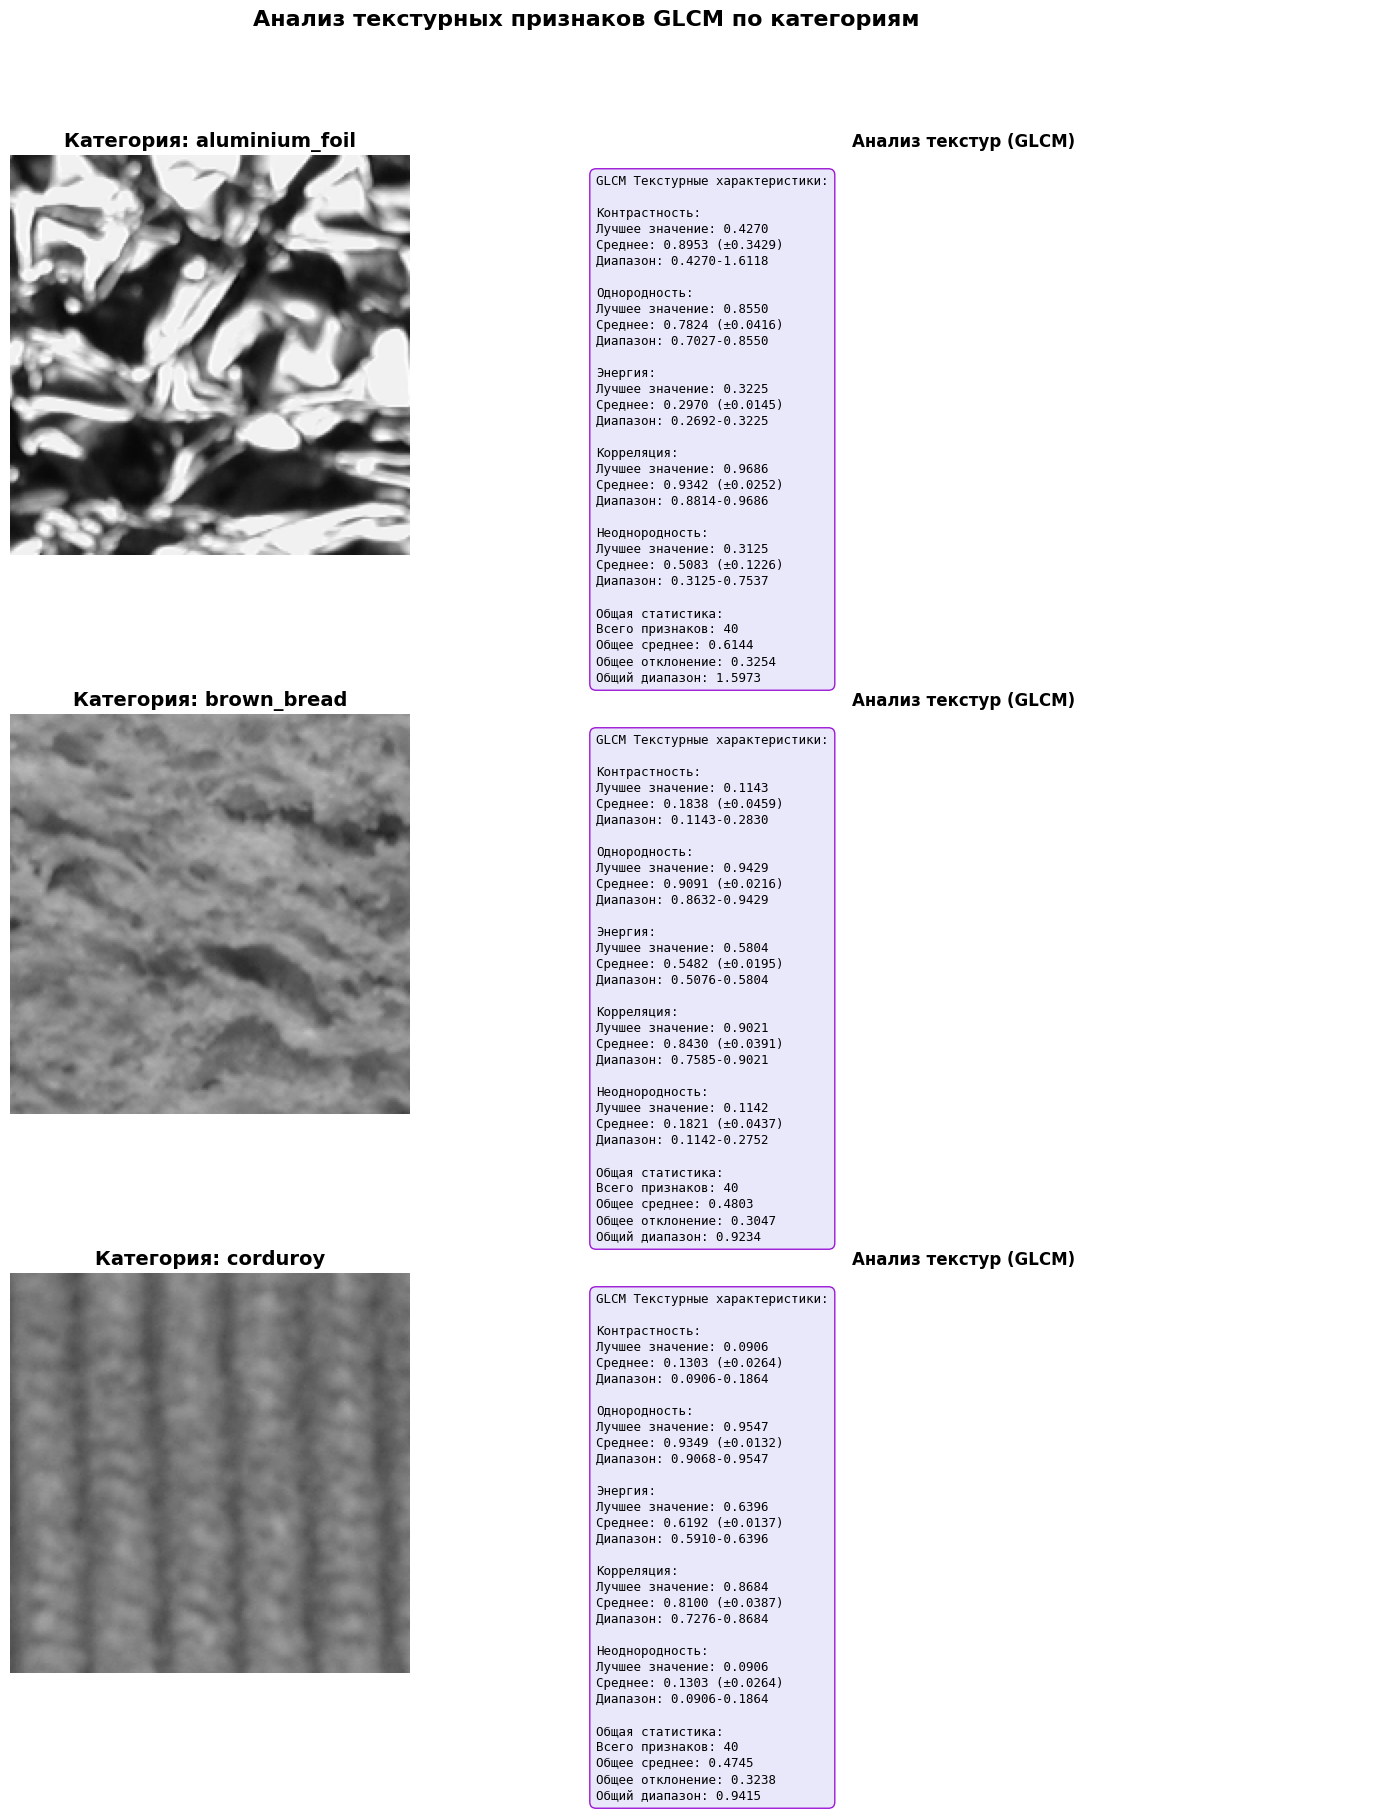

['aluminium_foil', 'brown_bread', 'corduroy']

In [10]:
analyze_glcm_categories("./KTH_TIPS", num_examples=3)

In [11]:
image_folder = "./KTH_TIPS"

if not os.path.exists(image_folder):
    raise FileNotFoundError(f"Папка с данными не найдена: {image_folder}")

image_paths = []
class_names = []

print(f"Поиск изображений в папке: {image_folder}")

for class_folder in os.listdir(image_folder):
    class_path = os.path.join(image_folder, class_folder)
    
    if os.path.isdir(class_path):
        class_names.append(class_folder)
        
        valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
        
        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(valid_extensions):
                file_path = os.path.join(class_path, file_name)
                image_paths.append(file_path)
        
        print(f"  Класс '{class_folder}': {len([f for f in os.listdir(class_path) 
                                               if f.lower().endswith(valid_extensions)])} изображений")

print(f"\nВсего найдено: {len(image_paths)} изображений в {len(class_names)} классах")


X_hist = []  
X_laws = [] 
X_glcm = []  
y = []       

total_images = len(image_paths)
print(f"\nНачата обработка {total_images} изображений...")

for i, image_path in enumerate(image_paths):
    if i % 20 == 0 or i == total_images - 1:
        print(f"  Прогресс: {i+1}/{total_images} изображений "
              f"({(i+1)/total_images*100:.1f}%)")
    
    try:
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        
        if image is None:
            print(f"    Предупреждение: Не удалось загрузить {image_path}")
            continue
        
        target_size = (128, 128)
        image_resized = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
        
        image_gray = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)
        
        hist_features, _, _ = histogram_features(image_resized)
        

        laws_features, _ = Laws_features(image_resized)
        
        glcm_features, _ = GLCM_features(image_gray)
        
        if (hist_features is not None and len(hist_features) > 0 and
            laws_features is not None and len(laws_features) > 0 and
            glcm_features is not None and len(glcm_features) > 0):
            
            X_hist.append(hist_features)
            X_laws.append(laws_features)
            X_glcm.append(glcm_features)
            
            label = os.path.basename(os.path.dirname(image_path))
            y.append(label)
        else:
            print(f"Предупреждение: Не удалось извлечь признаки для {image_path}")
            
    except Exception as e:
        print(f"Ошибка при обработке {image_path}: {str(e)}")
        continue

print(f"\nУспешно обработано: {len(X_hist)} изображений")

if len(X_hist) == 0:
    raise ValueError("Не удалось обработать ни одного изображения. Проверьте данные.")


def features_to_array(features_list, method_name=""):
    if not features_list:
        raise ValueError(f"Пустой список признаков для метода {method_name}")
    
    feature_arrays = []
    feature_names = None
    
    for i, features in enumerate(features_list):
        if not isinstance(features, dict):
            raise ValueError(f"Признаки для метода {method_name} должны быть словарем")

        if feature_names is None:
            feature_names = list(features.keys())
        
        try:
            values = [features[key] for key in feature_names]
            feature_arrays.append(values)
        except KeyError as e:
            print(f"Ошибка: Несогласованные признаки в методе {method_name}")
            raise e
    

    array = np.array(feature_arrays, dtype=np.float32)
    
    print(f"  Метод {method_name}: {array.shape[0]} образцов × {array.shape[1]} признаков")
    
    if np.any(np.isnan(array)):
        print(f"Предупреждение: В методе {method_name} обнаружены NaN значения")
        array = np.nan_to_num(array, nan=0.0)
    
    if np.any(np.isinf(array)):
        print(f"Предупреждение: В методе {method_name} обнаружены Inf значения")
        array = np.where(np.isinf(array), 0.0, array)
    
    return array, feature_names

print("\nПреобразование признаков в массивы...")

try:
    X_hist_array, hist_feature_names = features_to_array(X_hist, "Histogram")
    X_laws_array, laws_feature_names = features_to_array(X_laws, "Laws")
    X_glcm_array, glcm_feature_names = features_to_array(X_glcm, "GLCM")
except Exception as e:
    print(f"Ошибка при преобразовании признаков: {e}")
    raise

num_samples = X_hist_array.shape[0]
if not (X_laws_array.shape[0] == X_glcm_array.shape[0] == num_samples):
    raise ValueError(f"Несогласованное количество образцов: "
                     f"Histogram={X_hist_array.shape[0]}, "
                     f"Laws={X_laws_array.shape[0]}, "
                     f"GLCM={X_glcm_array.shape[0]}")


print("\nКодирование меток классов...")
y = np.array(y)
unique_classes = np.unique(y)
print(f"  Уникальные классы ({len(unique_classes)}): {', '.join(unique_classes)}")

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"  Закодированные метки: {y_encoded.shape}")

methods = {
    'Histogram': X_hist_array,
    'Laws': X_laws_array, 
    'GLCM': X_glcm_array
}


feature_names_dict = {
    'Histogram': hist_feature_names,
    'Laws': laws_feature_names, 
    'GLCM': glcm_feature_names
}

models = {
    'kNN': KNeighborsClassifier(
        n_neighbors=3,
        weights='distance',
        metric='minkowski',
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42,
        probability=True
    ),  
    'DecisionTree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        criterion='gini'
    )
}

print("\n" + "="*60)
print("ИТОГОВАЯ ИНФОРМАЦИЯ:")
print("="*60)
print(f"Общее количество образцов: {num_samples}")
print(f"Количество классов: {len(unique_classes)}")
print("\nРазмеры признаковых пространств:")
for method_name, X_array in methods.items():
    print(f"  {method_name}: {X_array.shape[1]} признаков")
print(f"\nИспользуемые модели: {', '.join(models.keys())}")
print("="*60)

data_summary = {
    'X_hist': X_hist_array,
    'X_laws': X_laws_array,
    'X_glcm': X_glcm_array,
    'y': y,
    'y_encoded': y_encoded,
    'label_encoder': le,
    'methods': methods,
    'feature_names': feature_names_dict,
    'models': models,
    'class_names': unique_classes.tolist(),
    'image_paths': image_paths[:num_samples]  
}

print("\nДанные успешно подготовлены для классификации!")

Поиск изображений в папке: ./KTH_TIPS
  Класс 'aluminium_foil': 81 изображений
  Класс 'brown_bread': 81 изображений
  Класс 'corduroy': 81 изображений
  Класс 'cotton': 81 изображений
  Класс 'cracker': 81 изображений
  Класс 'linen': 81 изображений
  Класс 'orange_peel': 81 изображений
  Класс 'sandpaper': 81 изображений
  Класс 'sponge': 81 изображений
  Класс 'styrofoam': 81 изображений

Всего найдено: 810 изображений в 10 классах

Начата обработка 810 изображений...
  Прогресс: 1/810 изображений (0.1%)
  Прогресс: 21/810 изображений (2.6%)
  Прогресс: 41/810 изображений (5.1%)
  Прогресс: 61/810 изображений (7.5%)
  Прогресс: 81/810 изображений (10.0%)
  Прогресс: 101/810 изображений (12.5%)
  Прогресс: 121/810 изображений (14.9%)
  Прогресс: 141/810 изображений (17.4%)
  Прогресс: 161/810 изображений (19.9%)
  Прогресс: 181/810 изображений (22.3%)
  Прогресс: 201/810 изображений (24.8%)
  Прогресс: 221/810 изображений (27.3%)
  Прогресс: 241/810 изображений (29.8%)
  Прогресс: 26

In [12]:
trained_models = {}

for method_name, X in methods.items():
    print(f"\n{method_name.upper()}")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    method_models = {}
    
    for model_name, model_template in models.items():
        if model_name == 'kNN':
            current_model = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
        elif model_name == 'SVM':
            current_model = SVC(kernel='rbf', random_state=42)
        elif model_name == 'DecisionTree':
            current_model = DecisionTreeClassifier(random_state=42, max_depth=10)
        
        if model_name == 'SVM':
            current_model.fit(X_train_scaled, y_train)
            y_pred = current_model.predict(X_test_scaled)
            method_models[model_name] = (current_model, scaler)
        else:
            current_model.fit(X_train, y_train)
            y_pred = current_model.predict(X_test)
            method_models[model_name] = current_model
        
        print(f"{model_name}")
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        print()
    
    trained_models[method_name] = method_models

selected_models = {
    'Histogram_kNN': trained_models['Histogram']['kNN'],  
    'Laws_Tree': trained_models['Laws']['DecisionTree'],                      
    'Laws_SVM': trained_models['Laws']['SVM']                                     
}


HISTOGRAM
kNN
                precision    recall  f1-score   support

aluminium_foil       0.95      1.00      0.98        20
   brown_bread       0.90      0.95      0.93        20
      corduroy       0.58      0.70      0.64        20
        cotton       0.55      0.52      0.54        21
       cracker       0.83      0.71      0.77        21
         linen       0.76      0.65      0.70        20
   orange_peel       0.94      0.76      0.84        21
     sandpaper       0.39      0.35      0.37        20
        sponge       0.64      0.80      0.71        20
     styrofoam       0.91      1.00      0.95        20

      accuracy                           0.74       203
     macro avg       0.75      0.74      0.74       203
  weighted avg       0.75      0.74      0.74       203


SVM
                precision    recall  f1-score   support

aluminium_foil       0.95      1.00      0.98        20
   brown_bread       0.94      0.80      0.86        20
      corduroy       0.6

In [13]:
def segment_sandwich(model_info, model_name, image_path, patch_size=32, step=16, n_classes=4):
    gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    height, width = gray_image.shape
    
    segmentation_map = np.zeros((height, width), dtype=np.uint8)
    predictions_list = []
    patch_positions = []
    
    for start_y in range(0, height - patch_size + 1, step):
        for start_x in range(0, width - patch_size + 1, step):
            image_patch = gray_image[start_y:start_y+patch_size, start_x:start_x+patch_size]
            
            if 'Histogram' in model_name:
                features_dict, _, _ = histogram_features(image_patch)
                feature_vector = np.array(list(features_dict.values()))
            elif 'Laws' in model_name:
                features_dict, _ = Laws_features(image_patch)
                feature_vector = np.array(list(features_dict.values()))
            elif 'GLCM' in model_name:
                features_dict, _ = GLCM_features(image_patch)
                feature_vector = np.array(list(features_dict.values()))
            
            if isinstance(model_info, tuple): 
                classifier, feature_scaler = model_info
                scaled_features = feature_scaler.transform(feature_vector.reshape(1, -1))
                predicted_class = classifier.predict(scaled_features)[0]
            else:  
                classifier = model_info
                predicted_class = classifier.predict(feature_vector.reshape(1, -1))[0]
            
            segmentation_map[start_y:start_y+patch_size, start_x:start_x+patch_size] = predicted_class
            predictions_list.append(predicted_class)
            patch_positions.append((start_y, start_x))
    
    unique_classes, class_counts = np.unique(predictions_list, return_counts=True)
    top_n_classes = unique_classes[np.argsort(class_counts)[-n_classes:]]
    
    filtered_segmentation = np.zeros_like(segmentation_map)
    
    for new_class_index, original_class in enumerate(top_n_classes):
        filtered_segmentation[segmentation_map == original_class] = new_class_index
    
    non_top_mask = ~np.isin(segmentation_map, top_n_classes)
    if np.any(non_top_mask):
        filtered_segmentation[non_top_mask] = 1
    
    return filtered_segmentation

Обрабатываем: Histogram_kNN
Успешно
Обрабатываем: Laws_Tree
Успешно
Обрабатываем: Laws_SVM
Успешно


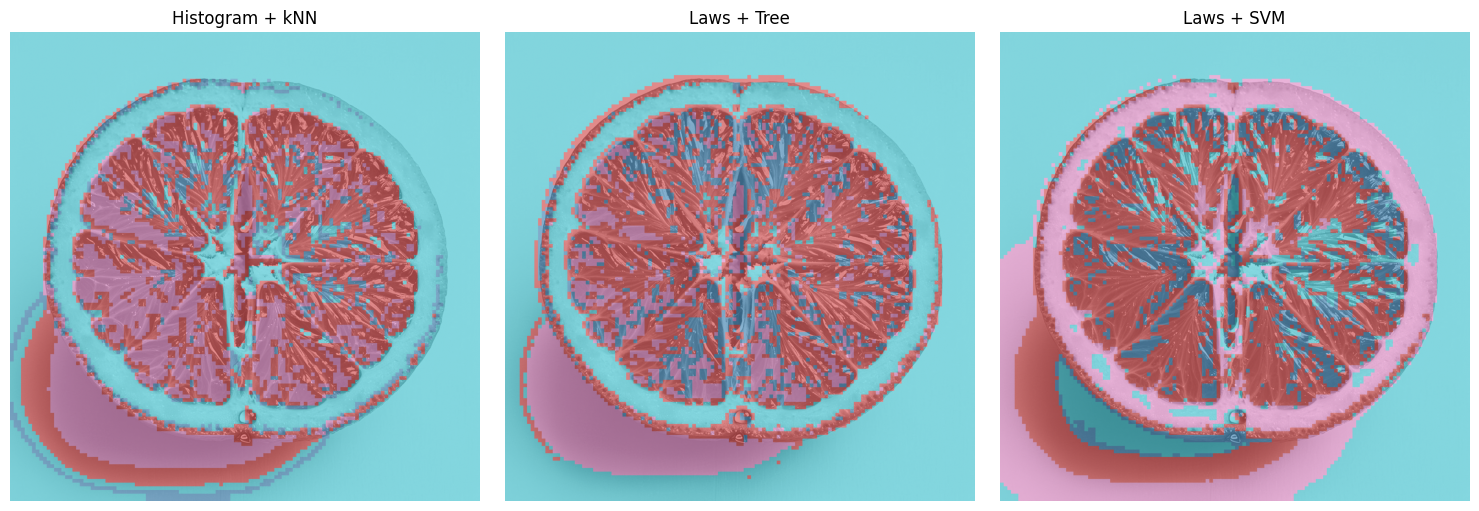

In [14]:
image_path = "./im/image.jpeg"
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

target_mask = None

if original_image is not None:
    segmentation_maps = []
    selected_model_names = []
    
    for current_model_name, current_model_info in selected_models.items():
        print(f"Обрабатываем: {current_model_name}")
        
        segmentation_result = segment_sandwich(
            current_model_info, 
            current_model_name, 
            image_path, 
            patch_size=16, 
            step=8
        )
        
        if segmentation_result is not None:
            segmentation_maps.append(segmentation_result)
            selected_model_names.append(current_model_name)
            print(f"Успешно")
        else:
            print(f"Ошибка")

    for idx, model_label in enumerate(selected_model_names):
        if model_label == 'Laws_SVM':
            target_mask = segmentation_maps[idx]
            break

    if target_mask is None and len(segmentation_maps) > 0:
        target_mask = segmentation_maps[0]
        print(f"Внимание: Laws_SVM не найден, используем {selected_model_names[0]}")
    
    if segmentation_maps:
        visualization_fig, axes_grid = plt.subplots(1, 3, figsize=(15, 5))
        
        for plot_idx, (segmentation_data, model_label) in enumerate(zip(segmentation_maps, selected_model_names)):
            if 'Histogram' in model_label:
                feature_method = 'Histogram'
                algorithm_type = 'kNN'
            elif 'Laws' in model_label:
                feature_method = 'Laws'
                if 'Tree' in model_label:
                    algorithm_type = 'Tree'
                else:
                    algorithm_type = 'SVM'
            
            axes_grid[plot_idx].imshow(original_image, cmap='gray', alpha=0.7)
            axes_grid[plot_idx].imshow(segmentation_data, cmap='tab10', alpha=0.5)
            axes_grid[plot_idx].set_title(f'{feature_method} + {algorithm_type}', fontsize=12)
            axes_grid[plot_idx].axis('off')
        
        plt.tight_layout()
        plt.show()

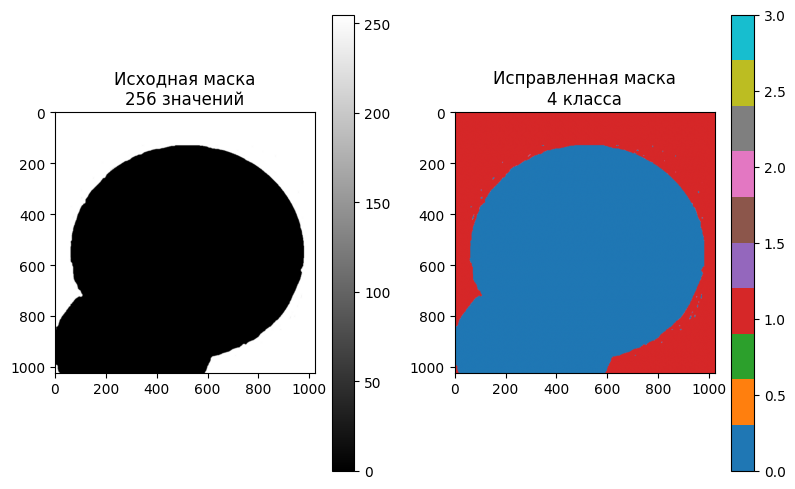

In [15]:
def keep_top_colors(input_mask, n_colors=4):  
    unique_values, value_counts = np.unique(input_mask, return_counts=True)
    
    sorted_by_frequency = np.argsort(-value_counts)
    most_frequent_colors = unique_values[sorted_by_frequency[:n_colors]]
    
    processed_mask = np.zeros_like(input_mask)
    
    for new_index, original_value in enumerate(most_frequent_colors):
        processed_mask[input_mask == original_value] = new_index
    
    return processed_mask

manual_mask_path = "./im/mask.png"
original_mask = cv2.imread(manual_mask_path, cv2.IMREAD_GRAYSCALE)
corrected_mask = keep_top_colors(original_mask, n_colors=4)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_mask, cmap='gray')
plt.title(f'Исходная маска\n{len(np.unique(original_mask))} значений')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(corrected_mask, cmap='tab10')
plt.title('Исправленная маска\n4 класса')
plt.colorbar()

plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import accuracy_score, jaccard_score

In [17]:
def compare_simple(manual_mask, predicted_mask, model_name, original_img):
    print(f"\nСравнение для {model_name}:")
    print(f"Размер ручной маски: {manual_mask.shape}")
    print(f"Размер предсказанной маски: {predicted_mask.shape}")
    
    min_height = min(manual_mask.shape[0], predicted_mask.shape[0])
    min_width = min(manual_mask.shape[1], predicted_mask.shape[1])
    
    manual_cropped = manual_mask[:min_height, :min_width]
    predicted_cropped = predicted_mask[:min_height, :min_width]
    
    print(f"Размер после обрезки: {manual_cropped.shape}")
    
    class_correspondence = {}
    for predicted_class in np.unique(predicted_cropped):
        manual_values, frequency_counts = np.unique(
            manual_cropped[predicted_cropped == predicted_class], 
            return_counts=True
        )
        
        if len(manual_values) > 0:
            most_frequent_manual = manual_values[np.argmax(frequency_counts)]
            class_correspondence[predicted_class] = most_frequent_manual
            print(f"  Предсказанный класс {predicted_class} -> Ручной класс {most_frequent_manual}")
    
    mapped_prediction = np.zeros_like(predicted_cropped)
    for pred_class, manual_class in class_correspondence.items():
        mapped_prediction[predicted_cropped == pred_class] = manual_class
    
    accuracy_value = accuracy_score(manual_cropped.flatten(), mapped_prediction.flatten())
        
    visualization_fig, axes_grid = plt.subplots(1, 3, figsize=(15, 5))
    
    original_cropped = original_img[:min_height, :min_width]
    
    axes_grid[0].imshow(original_cropped, cmap='gray')
    axes_grid[0].set_title('Оригинальное изображение')
    axes_grid[0].axis('off')
    
    axes_grid[1].imshow(manual_cropped, cmap='tab10')
    axes_grid[1].set_title('Ручная разметка')
    axes_grid[1].axis('off')

    axes_grid[2].imshow(predicted_cropped, cmap='tab10')
    axes_grid[2].set_title('Предсказанная разметка (оригинал)')
    axes_grid[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return accuracy_value


Сравнение для Laws_SVM:
Размер ручной маски: (1024, 1024)
Размер предсказанной маски: (1024, 1024)
Размер после обрезки: (1024, 1024)
  Предсказанный класс 0 -> Ручной класс 0
  Предсказанный класс 1 -> Ручной класс 0
  Предсказанный класс 2 -> Ручной класс 0
  Предсказанный класс 3 -> Ручной класс 1


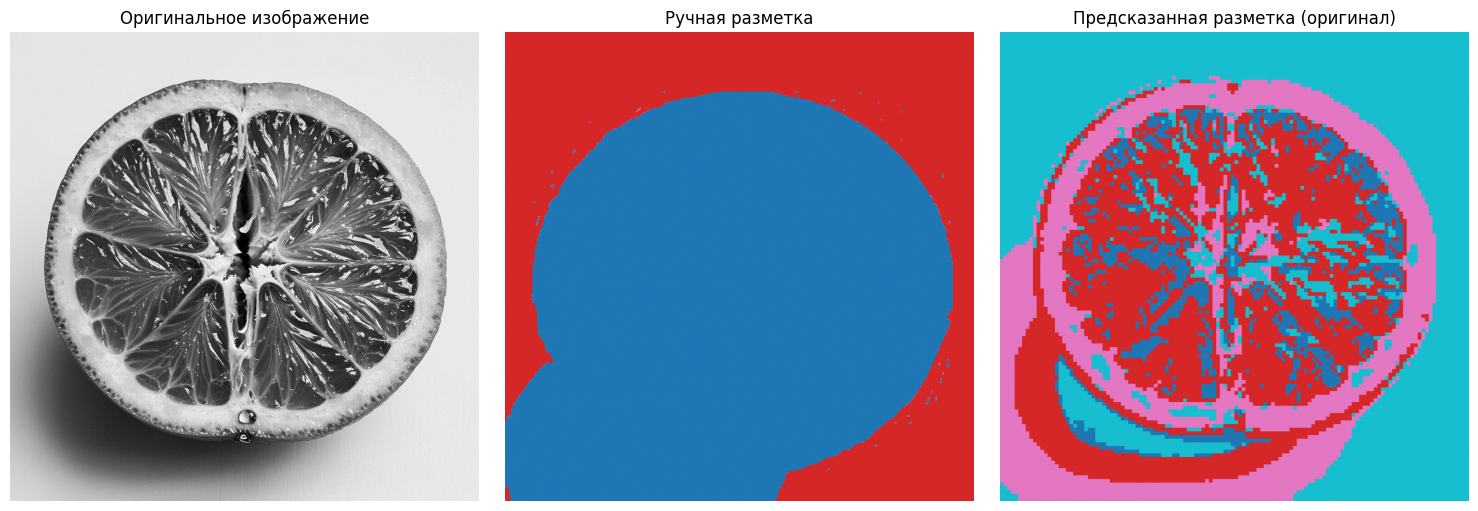

Итог: 85.5% правильных пикселей


In [19]:
image_path = "./im/image.jpeg"
original_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if corrected_mask is not None and target_mask is not None and original_img is not None:
    accuracy_score = compare_simple(corrected_mask, target_mask, 'Laws_SVM', original_img)
    print(f"Итог: {accuracy_score * 100:.1f}% правильных пикселей")